## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.



__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : Personalized Learning Through Student Behavior Clustering Using ASSISTments Data

## Problem Statement

Online learning platforms such as ASSISTments collect rich data about student interactions, including response accuracy, response time, attempts, and hint usage. However, students often receive similar learning experiences despite having different learning behaviors.

This project applies clustering techniques to group students with similar learning behaviors and generate meaningful learning profiles. These profiles can help educators and intelligent tutoring systems provide personalized learning experiences, targeted interventions, and data-driven instructional support to improve student outcomes.

## Data Info
Data Source : https://sites.google.com/site/assistmentsdata/home/2009-2010-assistment-data/skill-builder-data-2009-2010

## Data Dictionary

| Feature | Data Type | Description |
|---------|----------|-------------|
| **order_id** | Integer | Chronological identifier of the student's interaction. Larger values indicate later interactions. |
| **assignment_id** | Integer | Unique identifier of the assignment (homework or activity) created by a teacher for a class. Different teachers can assign the same content but have different assignment IDs. |
| **user_id** | Integer | Unique identifier for each student. |
| **assistment_id** | Integer | Identifier of the ASSISTment (tutoring activity). One ASSISTment may contain multiple related problems or scaffold questions. |
| **problem_id** | Integer | Unique identifier for an individual problem. |
| **original** | Binary (0/1) | Indicates whether the problem is the original question (`1`) or a scaffold/help question (`0`). |
| **correct** | Binary (0/1) | Indicates whether the student answered correctly on the first attempt (`1`) or answered incorrectly/requested help (`0`). This is commonly used as the target variable. |
| **attempt_count** | Integer | Number of attempts the student made before completing the problem. |
| **ms_first_response** | Integer | Time (in milliseconds) between displaying the problem and the student's first response. |
| **tutor_mode** | Categorical | Learning mode during the interaction. Possible values include `tutor`and `test` |
| **answer_type** | Categorical | Type of expected answer (e.g., `choose_1`, `algebra`, `fill_in`, `open_response`). |
| **sequence_id** | Integer | Identifier of the problem set. Multiple assignments can share the same sequence if they use the same problem set. |
| **student_class_id** | Integer | Identifier of the student's classroom or class section. |
| **position** | Integer | Position of the assignment on the student's assignment page. |
| **problem_set_type** | Categorical | Organization of the problem set. Possible values include `Linear`, `Random`, and `Mastery`. |
| **base_sequence_id** | Integer | Identifier of the original sequence from which the current sequence was copied. If not copied, it is equal to `sequence_id`. |
| **skill_id** | Integer | Identifier of the mathematical skill associated with the problem. In the Skill Builder dataset, each row contains only one skill. Multi-skill problems are duplicated into multiple rows. |
| **skill_name** | String | Name of the mathematical skill associated with the problem. |
| **teacher_id** | Integer | Unique identifier of the teacher who assigned the problem. |
| **school_id** | Integer | Unique identifier of the school. |
| **hint_count** | Integer | Number of hints requested by the student while solving the problem. |
| **hint_total** | Integer | Total number of hints available for the problem. |
| **overlap_time** | Integer | Time (in milliseconds) representing overlapping student activity while interacting with the problem. |
| **template_id** | Integer | Identifier of the ASSISTment template. Problems sharing the same template have similar structures but different values. |
| **answer_id** | Integer | Identifier of the selected answer for multiple-choice questions. |
| **answer_text** | String | Student's submitted answer for fill-in or text-based questions. |
| **first_action** | Categorical | Student's first action after viewing the problem, such as `attempt` or `hint`. |
| **bottom_hint** | Binary (0/1) | Indicates whether the student requested the bottom-out hint (the final hint revealing the solution). |
| **opportunity** | Integer | Number of previous opportunities the student has had to practice the associated skill. |
| **opportunity_original** | Integer | Number of previous opportunities the student has had to practice the skill considering only original problems (`original = 1`). |

---

# Target Variable

| Feature | Description |
|---------|-------------|
| **correct** | Binary target variable indicating whether the student answered the problem correctly on the first attempt. `1` = Correct, `0` = Incorrect or requested help. |

---

# Feature Categories

| Category | Features |
|----------|----------|
| **Student Information** | `user_id`, `student_class_id`, `teacher_id`, `school_id` |
| **Assignment Information** | `assignment_id`, `sequence_id`, `base_sequence_id`, `position`, `problem_set_type` |
| **Problem Information** | `assistment_id`, `problem_id`, `template_id`, `original` |
| **Skill Information** | `skill_id`, `skill_name`, `opportunity`, `opportunity_original` |
| **Student Behavior** | `attempt_count`, `hint_count`, `hint_total`, `ms_first_response`, `overlap_time`, `first_action`, `bottom_hint` |
| **Response Information** | `correct`, `answer_type`, `answer_id`, `answer_text` |

---

# Notes

- **`correct`** is the primary target variable used in most machine learning tasks on this dataset.
- The **Skill Builder** version stores **one skill per row**. If a problem assesses multiple skills, the interaction is duplicated so that each row corresponds to a single skill.
- Time-related features (`ms_first_response`, `overlap_time`) are measured in **milliseconds (ms)**.
- Columns ending with `_id` are identifiers and generally should not be treated as continuous numerical variables. Depending on the modeling approach, they may be removed, encoded, or used for grouping.
- `opportunity` and `opportunity_original` are important educational features because they measure how many times a student has previously practiced a skill, making them valuable predictors of student mastery.

In [55]:
# start you EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

#### What is your target column and what does it represent? 
**Target Column:** None

**Representation:** This project uses an **unsupervised learning (clustering)** approach, so there is no target column. Instead, the model groups students based on similarities in their learning behaviors, such as response accuracy, response time, number of attempts, hint usage, and practice opportunities. The resulting clusters represent different student learning profiles that can be used to support personalized learning experiences.

In [33]:
df = pd.read_csv('data/skill_builder_data_corrected_collapsed.csv', encoding='latin-1')

C:\Users\elias\AppData\Local\Temp\ipykernel_17468\102637691.py:1: DtypeWarning: Columns (0: skill_id, 1: skill_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/skill_builder_data_corrected_collapsed.csv', encoding='latin-1')


In [34]:
pd.set_option('display.max_columns', None)

df.head()

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,5,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1_15,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [35]:
df.shape

(346860, 31)

#### Is your target categorical or continuous? is it balanced (Plot the distribution)? categorical, Not balance

This project uses an **unsupervised learning (clustering)** approach, so there is no target variable to classify as categorical or continuous. Consequently, target class balance and target distribution are not applicable. Instead, the analysis focuses on the distribution of the input features used to group students into learning profiles.

#### What types of features do you have (categorical / numerical)? how many of each ?

In [37]:
df.columns

Index(['Unnamed: 0', 'order_id', 'assignment_id', 'user_id', 'assistment_id',
       'problem_id', 'original', 'correct', 'attempt_count',
       'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id',
       'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id',
       'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total',
       'overlap_time', 'template_id', 'answer_id', 'answer_text',
       'first_action', 'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='str')

In [38]:
df['skill_name'].value_counts()

skill_name
Equation Solving Two or Fewer Steps         24253
Conversion of Fraction Decimals Percents    18742
Addition and Subtraction Integers           12741
Addition and Subtraction Fractions          11334
Equation Solving More Than Two Steps         8115
                                            ...  
Distributive Property                          18
Finding Slope From Situation                    9
Recognize Quadratic Pattern                     8
Reading a Ruler or Scale                        5
Finding Slope from Ordered Pairs                5
Name: count, Length: 101, dtype: int64

In [39]:
df['tutor_mode'].value_counts()

tutor_mode
tutor    346601
test        259
Name: count, dtype: int64

In [40]:
df['answer_type'].value_counts()

answer_type
algebra          270780
choose_1          41181
fill_in_1         34786
choose_n            105
open_response         8
Name: count, dtype: int64

In [41]:
df['first_action'].value_counts()

first_action
0    309271
1     31273
2      6316
Name: count, dtype: int64

In [42]:
df['bottom_hint'].value_counts()

bottom_hint
1.0    42932
0.0    16925
Name: count, dtype: int64

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 346860 entries, 0 to 346859
Data columns (total 31 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Unnamed: 0            346860 non-null  int64  
 1   order_id              346860 non-null  int64  
 2   assignment_id         346860 non-null  int64  
 3   user_id               346860 non-null  int64  
 4   assistment_id         346860 non-null  int64  
 5   problem_id            346860 non-null  int64  
 6   original              346860 non-null  int64  
 7   correct               346860 non-null  int64  
 8   attempt_count         346860 non-null  int64  
 9   ms_first_response     346860 non-null  int64  
 10  tutor_mode            346860 non-null  str    
 11  answer_type           346860 non-null  str    
 12  sequence_id           346860 non-null  int64  
 13  student_class_id      346860 non-null  int64  
 14  position              346860 non-null  int64  
 15  type       

In [44]:
# df.drop(columns=['Unnamed: 0', 'tutor_mode', 'position', 'teacher_id', 'school_id', 'bottom_hint','answer_text','answer_id'], inplace=True)

## Feature Types

The dataset contains **31 features**, which can be categorized as follows:

### Categorical Features (5)

- `tutor_mode`
- `answer_type`
- `type`
- `skill_name`
- `answer_text`

### Numerical Features (26)

- `Unnamed: 0`
- `order_id`
- `assignment_id`
- `user_id`
- `assistment_id`
- `problem_id`
- `original`
- `correct`
- `attempt_count`
- `ms_first_response`
- `sequence_id`
- `student_class_id`
- `position`
- `base_sequence_id`
- `skill_id`
- `teacher_id`
- `school_id`
- `hint_count`
- `hint_total`
- `overlap_time`
- `template_id`
- `answer_id`
- `first_action`
- `bottom_hint`
- `opportunity`
- `opportunity_original`

> **Note:** Several numerical columns (e.g., `user_id`, `problem_id`, `skill_id`, `teacher_id`, and `school_id`) are identifier (ID) features. Although stored as numerical values, they represent unique identifiers rather than continuous numerical measurements and are typically removed or treated separately during preprocessing.

## How many null values does each feature have? what's your plan for each?

In [45]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63755
skill_name               72270
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               306818
answer_text              77630
first_action                 0
bottom_hint             287003
opportunity                  0
opportunity_original     71402
dtype: int64

## Missing Values and Handling Plan

| Feature | Missing Values | Handling Plan |
|---------|---------------:|---------------|
| `Unnamed: 0` | 0 | No action required. |
| `order_id` | 0 | No action required. |
| `assignment_id` | 0 | No action required. |
| `user_id` | 0 | No action required. |
| `assistment_id` | 0 | No action required. |
| `problem_id` | 0 | No action required. |
| `original` | 0 | No action required. |
| `correct` | 0 | Target column; no missing values. |
| `attempt_count` | 0 | No action required. |
| `ms_first_response` | 0 | No action required. |
| `tutor_mode` | 0 | No action required. |
| `answer_type` | 0 | No action required. |
| `sequence_id` | 0 | No action required. |
| `student_class_id` | 0 | No action required. |
| `position` | 0 | No action required. |
| `type` | 0 | No action required. |
| `base_sequence_id` | 0 | No action required. |
| `skill_id` | 63,755 | Fill missing values using the corresponding `skill_name` (or vice versa) since they represent the same skill. Remove rows only if both are missing. |
| `skill_name` | 72,270 | Fill missing values using the corresponding `skill_id` through a mapping table. |
| `teacher_id` | 0 | No action required. |
| `school_id` | 0 | No action required. |
| `hint_count` | 0 | No action required. |
| `hint_total` | 0 | No action required. |
| `overlap_time` | 0 | No action required. |
| `template_id` | 0 | No action required. |
| `answer_id` | 306,818 | Drop this column because it is an identifier and has a large number of missing values. |
| `answer_text` | 77,630 | Replace missing values with `"Unknown"` (or the mode) if the feature is used; otherwise, remove the column if it is not relevant to the model. |
| `first_action` | 0 | No action required. |
| `bottom_hint` | 287,003 | Replace missing values with `0` (indicating no bottom hint was used). |
| `opportunity` | 0 | No action required. |
| `opportunity_original` | 71,402 | Fill missing values using `opportunity` where appropriate, since they are closely related. |

### Summary
- **Features with missing values:** 6
- **Features without missing values:** 25

**Planned preprocessing:**
- Use mapping between `skill_id` and `skill_name` to recover missing skill information.
- Drop `answer_id` because it is an identifier with many missing values.
- Impute `answer_text` with `"Unknown"` if retained.
- Fill `bottom_hint` with `0`.
- Fill `opportunity_original` from `opportunity` when possible.

## Which features are most correlated with your target, and with each other?


## Correlation Analysis

Since this project uses an **unsupervised learning (clustering)** approach, there is **no target variable**. Therefore, correlation analysis is used to identify relationships among the input features and detect redundant variables before clustering.

### Observations

- **`opportunity` and `opportunity_original`** have an **extremely strong positive correlation (0.98)**, indicating that they contain nearly the same information. One of these features can be removed to reduce redundancy.
- **`ms_first_response` and `overlap_time`** show a **very strong positive correlation (0.94)**, suggesting that students who spend more time responding also tend to have higher overlap time.
- **`hint_count` and `first_action`** have a **moderately strong positive correlation (0.63)**, indicating that students who request hints tend to have a similar first interaction behavior.
- **`hint_count` and `bottom_hint`** have a **moderate positive correlation (0.43)**, suggesting that students requesting more hints are also more likely to use bottom hints.
- Most of the remaining feature pairs have **weak correlations**, indicating that they provide different information and are unlikely to introduce significant redundancy.

### Feature Selection Decision

To improve clustering performance and reduce multicollinearity, one feature from each highly correlated pair (e.g., `opportunity_original` or `overlap_time`) may be removed before applying the clustering algorithm.

In [46]:
df.groupby("first_action")["hint_count"].mean()

first_action
0    0.274161
1    2.942570
2    0.000000
Name: hint_count, dtype: float64

In [47]:
df["first_action"].value_counts()

first_action
0    309271
1     31273
2      6316
Name: count, dtype: int64

In [48]:
df[df["first_action"] == 2][[
    "correct",
    "attempt_count",
    "hint_count",
    "hint_total",
    "answer_type",
    "tutor_mode"
]].describe(include="all")

,correct,attempt_count,hint_count,hint_total,answer_type,tutor_mode
count,6316.0,6316.000000,6316.0,6316.000000,6316,6316
unique,NaN,NaN,NaN,NaN,3,1
top,NaN,NaN,NaN,NaN,algebra,tutor
freq,NaN,NaN,NaN,NaN,5979,6316
mean,0.0,0.008708,0.0,0.131096,NaN,NaN
std,0.0,0.140422,0.0,0.613319,NaN,NaN
min,0.0,0.000000,0.0,0.000000,NaN,NaN
25%,0.0,0.000000,0.0,0.000000,NaN,NaN
50%,0.0,0.000000,0.0,0.000000,NaN,NaN
75%,0.0,0.000000,0.0,0.000000,NaN,NaN


In [49]:
df[df["first_action"] == 2].head(20)

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
3964,3965,21617692,263600,14,36838,57695,1,0,0,59891,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,59891,30397,NaN,NaN,2,NaN,8,8.0
3966,3967,21617749,263600,14,36822,57647,1,0,0,82572,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,82572,30397,NaN,NaN,2,NaN,10,10.0
3968,3969,21617825,263600,14,37068,58551,1,0,0,27225,tutor,algebra,5916,12495,2,MasterySection,5916,2_37_48_77,Circle Graph,42972,1,0,0,27225,30790,NaN,NaN,2,NaN,12,12.0
3983,3984,35305686,220655,70363,31403,47081,1,0,0,55499,tutor,algebra,5898,11816,3,MasterySection,5898,2_70,Circle Graph,22763,73,0,0,55499,30038,NaN,NaN,2,NaN,2,2.0
3986,3987,35307058,220655,70363,36823,57650,1,0,0,35562,tutor,algebra,5898,11816,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,35562,30397,NaN,NaN,2,NaN,5,5.0
4070,4071,30319263,220665,70872,37067,58548,1,0,0,13498,tutor,algebra,5916,11816,13,MasterySection,5916,2_37_48,Circle Graph,22763,73,0,0,13498,30790,NaN,NaN,2,NaN,1,1.0
4071,4072,30319442,220665,70872,36820,57641,1,0,0,32280,tutor,algebra,5916,11816,13,MasterySection,5916,2_48_79,Circle Graph,22763,73,0,0,32280,30397,NaN,NaN,2,NaN,2,2.0
4136,4137,20432779,232255,71826,36838,57695,1,0,0,250201,tutor,algebra,5898,11971,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,250201,30397,NaN,NaN,2,NaN,2,2.0
4144,4145,20427027,220655,71877,36843,57710,1,0,0,75467,tutor,algebra,5898,11816,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,75467,30397,NaN,NaN,2,NaN,2,2.0
4156,4157,35455538,277620,71881,36822,57647,1,0,0,1131591,tutor,algebra,5916,13241,128,MasterySection,5916,2_48_79,Circle Graph,22763,73,0,0,1131591,30397,NaN,NaN,2,NaN,9,9.0


In [50]:
df=df[
    df["first_action"] < 2
    ]

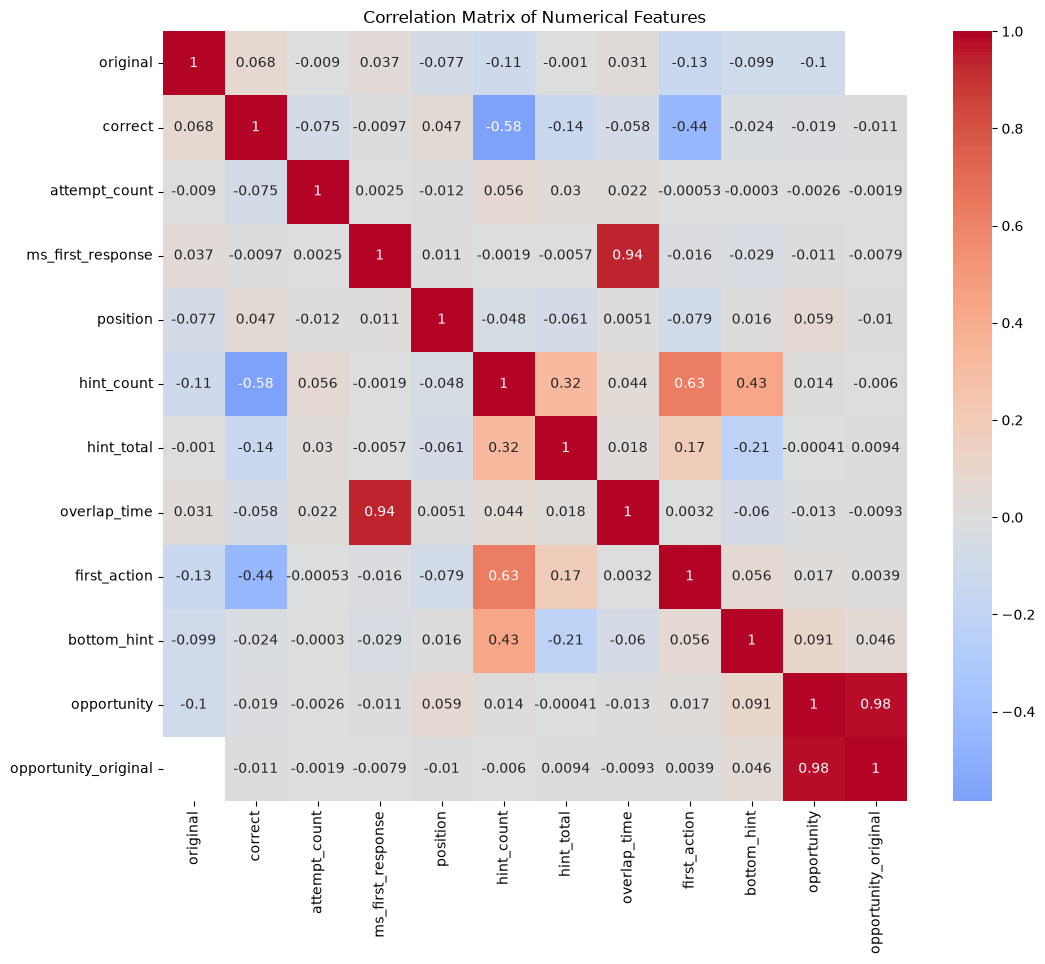

In [57]:
# Correlation with the target
# Select only numerical features
numeric_df = df.select_dtypes(include="number")

# (Optional) Remove columns that are IDs or not used in clustering
cols_to_drop = [
    "Unnamed: 0",
    "order_id",
    "user_id",
    "assignment_id",
    "assistment_id",
    "problem_id",
    "sequence_id",
    "base_sequence_id",
    "student_class_id",
    "teacher_id",
    "school_id",
    "template_id",
    "answer_id"
]

numeric_df = numeric_df.drop(columns=cols_to_drop, errors="ignore")

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

#### Are there outliers? how would you handle them?

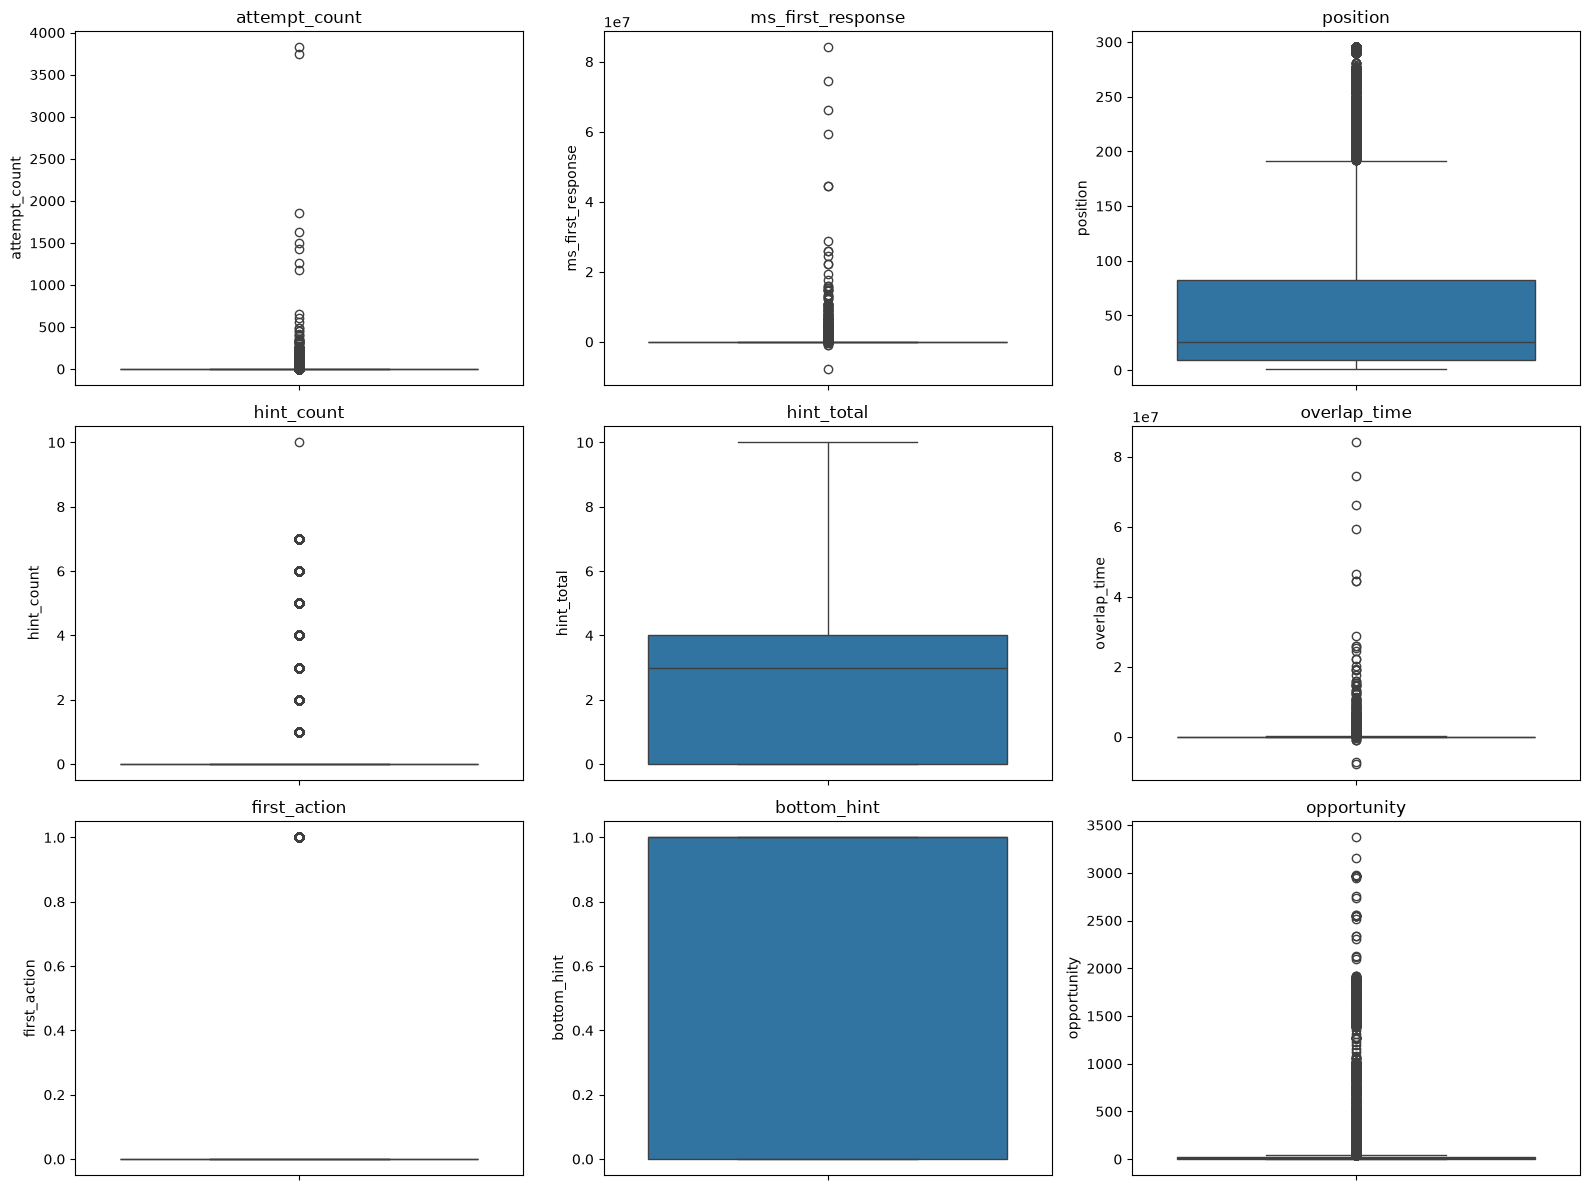

In [58]:
num_cols = [
    "attempt_count",
    "ms_first_response",
    "position",
    "hint_count",
    "hint_total",
    "overlap_time",
    "first_action",
    "bottom_hint",
    "opportunity"
]

plt.figure(figsize=(16, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [59]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Percentage": round(outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    by="Percentage",
    ascending=False
)

outlier_df

,Feature,Outliers,Percentage
0,attempt_count,71536,21.01
3,hint_count,59854,17.58
8,opportunity,39075,11.47
5,overlap_time,32681,9.60
1,ms_first_response,31638,9.29
6,first_action,31273,9.18
2,position,14746,4.33
4,hint_total,0,0.00
7,bottom_hint,0,0.00


## Outlier Analysis

The IQR method was used to detect outliers in the numerical features used for clustering.

| Feature | Outlier Percentage |
|---------|-------------------:|
| `attempt_count` | 21.01% |
| `hint_count` | 17.58% |
| `opportunity` | 11.47% |
| `overlap_time` | 9.60% |
| `ms_first_response` | 9.29% |
| `first_action` | 9.18% |
| `position` | 4.33% |
| `hint_total` | 0.00% |
| `bottom_hint` | 0.00% |

### Observations

- Several features contain a noticeable number of outliers, particularly `attempt_count`, `hint_count`, and `opportunity`.
- These values are expected in educational data and often represent meaningful differences in student learning behaviors rather than data entry errors.
- Features such as `hint_total` and `bottom_hint` contain no detected outliers.

### Handling Plan

The detected outliers will **not be removed**, as they may represent important learning patterns that are valuable for identifying distinct student groups. Instead, the numerical features will be scaled using an appropriate scaling technique (e.g., **RobustScaler**) to reduce the influence of extreme values while preserving meaningful behavioral differences for clustering.

In [25]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan forQ each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

# Topic 2 : Behavior-Based Product Group Recommendation Using Customer Clustering

## Problem Statement

E-commerce platforms collect vast amounts of customer interaction data, such as product views, cart additions, and purchases. However, many recommendation systems focus on suggesting individual products rather than groups of complementary products that better match customers' shopping behaviors. This can reduce recommendation relevance and limit cross-selling opportunities. This project aims to analyze customer behavior using machine learning to identify similar shopping patterns and recommend personalized groups of products, improving the shopping experience and recommendation effectiveness.

## Data Info
Data Source : https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store?select=2019-Nov.csv

# Data Dictionary

| Feature | Data Type | Description |
|---------|-----------|-------------|
| `event_time` | DateTime | The date and time when the customer interaction occurred (UTC). |
| `event_type` | Categorical | Type of customer interaction with the product (`view`, `cart`, `remove_from_cart`, `purchase`). |
| `product_id` | Integer | Unique identifier of the product. |
| `category_id` | Integer | Unique identifier of the product category. |
| `category_code` | Categorical | Hierarchical category name of the product (e.g., `electronics.smartphone`). |
| `brand` | Categorical | Brand name of the product. Some values may be missing. |
| `price` | Float | Price of the product. |
| `user_id` | Integer | Unique identifier of the customer. |
| `user_session` | Categorical | Unique identifier of the customer's browsing session. |

## What is your target column and what does it represent?
**Target Column:** None

**Representation:** This project uses an **unsupervised learning (clustering)** approach, so there is no target column. Instead, the model groups customers based on their shopping behaviors, such as product views, cart additions, purchases, product categories, brands, and spending patterns. The resulting clusters represent different customer segments that are used to recommend personalized groups of products.

## Basic EDA

In [60]:
df2 = pd.read_csv('data/2019-Nov.csv')
df2.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [61]:
pd.set_option('display.max_rows', None)
df2['category_code'].value_counts()

category_code
electronics.smartphone                    16375000
electronics.video.tv                       2208046
computers.notebook                         2180554
electronics.clocks                         2086966
apparel.shoes                              1886890
electronics.audio.headphone                1816877
appliances.environment.vacuum              1528058
appliances.kitchen.refrigerators           1427162
appliances.kitchen.washer                  1403866
computers.desktop                           690502
furniture.living_room.cabinet               551642
furniture.bedroom.bed                       532673
electronics.tablet                          492497
apparel.shoes.keds                          485802
auto.accessories.player                     473098
furniture.living_room.sofa                  425511
construction.tools.drill                    397860
appliances.kitchen.oven                     379338
kids.carriage                               347476
electronics.telep

In [62]:
df2.shape

(67501979, 9)

## Is your target categorical or continuous? Is it balanced?

**Target Type:** None

**Balanced:** Not applicable.

This project uses an **unsupervised learning (clustering)** approach, which does not require a target variable. Therefore, there is no target to classify as categorical or continuous, and target class balance is not applicable. Instead, the analysis focuses on the distribution of the input features (e.g., `event_type`, `price`, and customer behavior metrics) that are used to group similar customers.

## What types of features do you have (categorical / numerical)? how many of each ?

### Feature Types

The dataset contains **9 features**, which can be categorized as follows:

### Categorical Features (4)

- `event_type`
- `category_code`
- `brand`
- `user_session`

### Numerical Features (5)

- `event_time` *(DateTime feature)*
- `product_id`
- `category_id`
- `price`
- `user_id`

> **Note:** `event_time` is stored as a **DateTime** feature and will be converted into useful time-based attributes (e.g., hour, day, weekday, or month) during feature engineering. Additionally, `product_id`, `category_id`, and `user_id` are identifier (ID) features and will be used for aggregation rather than as continuous numerical variables.

In [64]:
df2.dtypes

event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object

## How many null values does each feature have? what's your plan for each?


### Missing Values and Handling Plan

| Feature | Missing Values | Handling Plan |
|---------|---------------:|---------------|
| `event_time` | 0 | No action required. |
| `event_type` | 0 | No action required. |
| `product_id` | 0 | No action required. |
| `category_id` | 0 | No action required. |
| `category_code` | 21,898,171 | Fill missing values using a mapping from `category_id` to `category_code`. If no mapping exists, replace with `"Unknown"` or remove the records if necessary. |
| `brand` | 9,224,078 | Replace missing values with `"Unknown"` since many products do not have a recorded brand. |
| `price` | 0 | No action required. |
| `user_id` | 0 | No action required. |
| `user_session` | 10 | Remove the 10 records with missing session IDs, as they represent a negligible portion of the dataset. |

### Summary

- **Features with missing values:** 3
- **Features without missing values:** 6

### Preprocessing Plan

- Recover missing `category_code` values using the corresponding `category_id` where possible.
- Replace missing `brand` values with `"Unknown"` because many products are unbranded or their brand is unavailable.
- Remove the 10 rows with missing `user_session` values due to their negligible impact on the dataset.

In [6]:
df2.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    21898171
brand             9224078
price                   0
user_id                 0
user_session           10
dtype: int64

In [65]:
mapping = (
    df2[['category_id', 'category_code']]
    .dropna()
    .drop_duplicates()
)

In [11]:
df2.groupby('category_id')['category_code'].nunique().sort_values(ascending=False).head()

category_id
2187707789055361298    1
2053013552226107603    1
2186437842832458550    1
2053013552293216471    1
2053013552326770905    1
Name: category_code, dtype: int64

## Which features are most correlated with your target, and with each other?

In [71]:
from scipy.stats import f_oneway

groups = [
    group["price"].values
    for _, group in df2.groupby("event_type")
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_value:.5f}")

F-statistic: 286.876
p-value: 0.00000


In [ ]:
df = df2.copy()

df["is_view"] = (df["event_type"] == "view").astype(int)
df["is_cart"] = (df["event_type"] == "cart").astype(int)
df["is_purchase"] = (df["event_type"] == "purchase").astype(int)


df["purchase_value"] = np.where(
    df["event_type"] == "purchase",
    df["price"],
    0
)


customer_features = (
    df.groupby("user_id")
      .agg(
          total_events=("event_type", "count"),
          total_views=("is_view", "sum"),
          total_carts=("is_cart", "sum"),
          total_purchases=("is_purchase", "sum"),
          total_spending=("purchase_value", "sum"),
          avg_interacted_price=("price", "mean"),
          unique_products=("product_id", "nunique"),
          unique_categories=("category_id", "nunique"),
          unique_brands=("brand", "nunique"),
          number_of_sessions=("user_session", "nunique"),
          first_event_time=("event_time", "min"),
          last_event_time=("event_time", "max")
      )
      .reset_index()
)

customer_features.head()

In [ ]:
avg_purchase_price = (
    df[df["event_type"] == "purchase"]
    .groupby("user_id")["price"]
    .mean()
    .rename("avg_purchase_price")
)

customer_features = customer_features.merge(
    avg_purchase_price,
    on="user_id",
    how="left"
)

In [ ]:
customer_features["avg_purchase_price"] = (
    customer_features["avg_purchase_price"].fillna(0)
)

In [ ]:
customer_features["view_to_cart_rate"] = np.where(
    customer_features["total_views"] > 0,
    customer_features["total_carts"] /
    customer_features["total_views"],
    0
)

customer_features["view_to_purchase_rate"] = np.where(
    customer_features["total_views"] > 0,
    customer_features["total_purchases"] /
    customer_features["total_views"],
    0
)

customer_features["cart_to_purchase_rate"] = np.where(
    customer_features["total_carts"] > 0,
    customer_features["total_purchases"] /
    customer_features["total_carts"],
    0
)

In [ ]:
customer_features["activity_days"] = (
    customer_features["last_event_time"] -
    customer_features["first_event_time"]
).dt.total_seconds() / 86400

In [ ]:
customer_features.columns

In [ ]:
clustering_features = [
    "total_events",
    "total_views",
    "total_carts",
    "total_purchases",
    "total_spending",
    "avg_interacted_price",
    "avg_purchase_price",
    "unique_products",
    "unique_categories",
    "unique_brands",
    "number_of_sessions",
    "view_to_cart_rate",
    "view_to_purchase_rate",
    "cart_to_purchase_rate",
    "activity_days"
]

X_cluster = customer_features[clustering_features]

In [ ]:
corr = X_cluster.corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Customer Features")
plt.show()

In [ ]:
category_levels = df2['category_code'].str.split('.', expand=True)

df2['category_level1'] = category_levels[0]
df2['category_level2'] = category_levels[1]
df2['category_level3'] = category_levels[2]

In [76]:
df2['category_level3'] = df2['category_level3'].fillna('None')

KeyError: 'level3'

In [ ]:
df2['brand'] = df2['brand'].fillna("Unknown")

In [ ]:
df2['event_time'] = pd.to_datetime(df['event_time'])

In [ ]:
# df2['Brand_Popularity']=
# df2['Total views per user'] = 
# df2['Total carts per user'] = 
# df2['Total purchases per user'] = 
# df2['Average purchases price'] = 
# df2['Brand Loyalty'] = 
# df2['Favorite Category'] = 



In [ ]:
# Possible Feature engineering
# User Activity Level
# Repeat Product Purchase
# Price Category

# User Activity Level
# Product Popularity
# Conversion Rate
# User Purchase Count
# Brand Frequency

In [ ]:
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

# Topic 3 : [Your Title]

## Problem Statement

[your problem statment here]

## Data Info
Data Source :

## Data Dictionary
| Column    | Type    | Description |
| --------  | ------- | -------     |
| Id        | int     | unique identifier |

In [ ]:
df3 = pd.read_csv('')
df3.head()

In [ ]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?